# Feature Engineering for Financial Time Series

This project focuses on feature engineering techniques for financial time series that are consistent with the empirical behavior of markets.

Rather than training predictive models, the goal is to construct meaningful features that respect stylized facts such as non-normality, volatility clustering, and time dependence.

This notebook builds on previous projects analyzing financial returns and volatility.


Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("default")


## Data Description

We use daily price data from the SPY ETF as a proxy for the U.S. equity market.

- Asset: SPY (S&P 500 ETF)
- Frequency: Daily
- Time horizon: Medium-term
- Variable of interest: Log-returns

Stylized facts analyzed here are robust across liquid financial markets and do not depend on the specific asset chosen.


Load Data

In [2]:
ticker = "SPY"
data = yf.download(ticker, start="2010-01-01", progress=False)

data.head()


/tmp/ipython-input-3517803808.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2010-01-01", progress=False)


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,85.027916,85.072930,83.662428,84.307659,118944600
2010-01-05,85.253036,85.290552,84.667828,84.975441,111579900
2010-01-06,85.313080,85.523154,85.103005,85.170527,116074400
2010-01-07,85.673180,85.778217,84.915407,85.155492,131091100
2010-01-08,85.958290,85.995806,85.275549,85.448107,126402800


Compute Log Returns

In [3]:
prices = data["Close"]

returns = np.log(prices / prices.shift(1))
returns = returns.dropna()

returns.head()


Ticker,SPY
Date,
2010-01-05,0.002644
2010-01-06,0.000704
2010-01-07,0.004212
2010-01-08,0.003322
2010-01-11,0.001396


## Why Feature Engineering Matters

Financial returns are noisy and exhibit weak linear predictability.

Applying machine learning directly to raw returns often leads to overfitting and poor out-of-sample performance.

Feature engineering aims to:
- Extract structure from noisy data
- Encode financial domain knowledge
- Align model inputs with market dynamics


Volatility Features

In [4]:
vol_20 = returns.rolling(window=20).std()
vol_60 = returns.rolling(window=60).std()


Visualize Volatility

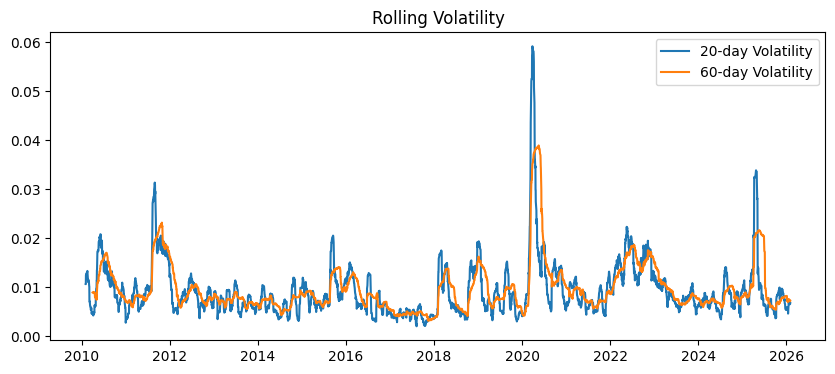

In [5]:
plt.figure(figsize=(10,4))
plt.plot(vol_20, label="20-day Volatility")
plt.plot(vol_60, label="60-day Volatility")
plt.legend()
plt.title("Rolling Volatility")
plt.show()


Return Transformations

In [6]:
abs_returns = returns.abs()
squared_returns = returns ** 2


Momentum Features

In [7]:
momentum_5 = prices.pct_change(5)
momentum_20 = prices.pct_change(20)


Lagged Returns

In [8]:
lagged_returns = pd.concat(
    [returns.shift(i) for i in range(1, 6)],
    axis=1
)

lagged_returns.columns = [f"lag_{i}" for i in range(1, 6)]


Feature Matrix

In [9]:
features = pd.concat(
    [
        vol_20,
        vol_60,
        abs_returns,
        squared_returns,
        momentum_5,
        momentum_20,
        lagged_returns
    ],
    axis=1
)

features.columns = [
    "vol_20",
    "vol_60",
    "abs_return",
    "squared_return",
    "momentum_5",
    "momentum_20"
] + list(lagged_returns.columns)

features = features.dropna()

features.head()


,vol_20,vol_60,abs_return,squared_return,momentum_5,momentum_20,lag_1,lag_2,lag_3,lag_4,lag_5
Date,,,,,,,,,,,
2010-03-31,0.004752,0.008902,0.003413,0.000012,0.001370,0.046143,0.000682,0.006328,-0.000601,-0.001627,-0.004867
2010-04-01,0.004859,0.008934,0.006814,0.000046,0.009858,0.050116,-0.003413,0.000682,0.006328,-0.000601,-0.001627
2010-04-05,0.004236,0.008986,0.008117,0.000066,0.018700,0.043756,0.006814,-0.003413,0.000682,0.006328,-0.000601
2010-04-06,0.004211,0.008977,0.002355,0.000006,0.014661,0.046033,0.008117,0.006814,-0.003413,0.000682,0.006328
2010-04-07,0.004574,0.009009,0.005729,0.000033,0.008177,0.038331,0.002355,0.008117,0.006814,-0.003413,0.000682


Sanity Checks

In [10]:
features.describe()


,vol_20,vol_60,abs_return,squared_return,momentum_5,momentum_20,lag_1,lag_2,lag_3,lag_4,lag_5
count,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000,3986.000000
mean,0.009248,0.009644,0.007198,0.000118,0.002845,0.011345,0.000518,0.000518,0.000518,0.000519,0.000517
std,0.005833,0.005109,0.008162,0.000449,0.022433,0.041600,0.010869,0.010869,0.010869,0.010869,0.010870
min,0.002007,0.003136,0.000000,0.000000,-0.179693,-0.309867,-0.115887,-0.115887,-0.115887,-0.115887,-0.115887
25%,0.005786,0.006811,0.001983,0.000004,-0.006977,-0.007777,-0.003709,-0.003709,-0.003709,-0.003709,-0.003711
50%,0.007718,0.008032,0.004893,0.000024,0.004552,0.016868,0.000694,0.000694,0.000694,0.000694,0.000694
75%,0.010919,0.010903,0.009647,0.000093,0.014868,0.035169,0.005771,0.005773,0.005773,0.005773,0.005773
max,0.059167,0.038925,0.115887,0.013430,0.173582,0.230725,0.099863,0.099863,0.099863,0.099863,0.099863


Note that features operate on different scales. Any modeling stage would require proper normalization using training data only to avoid leakage.


## Key Takeaways

- Raw returns are weak signals for machine learning
- Feature engineering encodes financial domain knowledge
- Volatility-based features capture persistent market structure
- Proper features are a prerequisite for any robust financial ML model

This project prepares the foundation for model evaluation and time-series validation in the next stage.
